# Practical 4: Density-based clustering

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names:**  
**Student Numbers:**  

---

## Assignment Overview

In this assignment, you will implement the Density-based spatial clustering of applications with noise (DBSCAN) algorithm as introduced and discussed in class, using Euclidean distance. Consider different settings for the parameter $minPts = 3,5,7$. Parameter eps will be optimised in the experiments. You will work with the same dataset `data_clustering.csv` used in Practical 2.


## 1. Introduction (1 point)

Describe the goal of this assignment. Your description should cover:

- The **problem** being solved
- The **experiments** performed
- The **algorithm** used
- The **dataset** used

**Your answer here:**

This assignment addresses the optimisation of DBSCAN model parameters for the unfamiliar, two-dimensional `data_clustering.csv` dataset. This objective is realised by implementing a DBSCAN algorithm based on Euclidean distance, constructing k-nearest neighbour (k-NN) graphs for $minPts \in \{3, 5, 7\}$ to ascertain the optimal $eps$, and subsequently validating the resulting parameters via the internal silhouette score index.

## 2. Methods (3.5 points)

### 2.1 Explain the DBSCAN algorithm (1 point)

Explain the algorithm in a general manner. Your explanation should describe all three components:

- **`DBSCAN`**: the main function - how it iterates over points and assigns cluster labels
- **`regionQuery`**: how it finds all neighbours within radius $\varepsilon$
- **`expand_cluster`**: how it grows a cluster from a core point

**Your answer here:**

#### DBSCAN

For every point within the dataset, determine the $\epsilon$-neighbourhood by executing a `regionQuery` and classify points as noise if their neighbourhood cardinality is strictly less than $minPts$. Conversely, if the neighbourhood size meets or exceeds this threshold (designating a core point), initialise a new cluster and proceed to augment it using the point and its associated neighbourhood by invoking the `expand_cluster` function.

#### Region Query

Calculate the Euclidean distance from the focal point to all other observations in the dataset and return exclusively the subset of points whose distance is less than or equal to $\epsilon$.

#### Expand Cluster

Assign the specified point to the current cluster. For each constituent point within its neighbourhood, ascertain their respective $\epsilon$-neighbourhoods by calling `regionQuery`. Should the cardinality of such a neighbourhood be greater than or equal to $minPts$, incorporate all points not yet assigned to a cluster into the cluster currently undergoing expansion. In instances where the corresponding neighbourhood is smaller than the threshold, append only the individual neighbouring point to the cluster.

### 2.2 Implementation (2.5 points)

You need to implement the DBSCAN algorithm **yourself**. Code and implementation itself will also be taken into account for the grading of this section.


*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [93]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Data configuration
data_file_path = "data_clustering.csv"

In [94]:
# Read input data
df = pd.read_csv(data_file_path, header=None)
data = np.array(df)

In [95]:
def DBSCAN(D, eps, MinPts):
    """
    Density-based spatial clustering of applications with noise (DBSCAN)

    Args:
        D (ndarray): Data points.
        eps (float): The radius of the neighbourhood around a data point
        MinPts (int): The minimum number of points to form a dense region

    Return:
      labels (ndarray): The corresponding cluster labels.

    """
    cluster_id = 0
    labels = np.zeros(len(D), dtype=int)

    for i, _ in enumerate(D):
        if labels[i] != 0:
            continue

        neighbors = regionQuery(D, i, eps)

        if len(neighbors) >= MinPts:
            cluster_id += 1

            expand_cluster(D, labels, i, neighbors, cluster_id, eps, MinPts)
        else:
            labels[i] = -1 # Noise

    return labels


def regionQuery(D, point_idx, eps):
    """
    Return indices of all points within eps of point_idx.

    Args:
        D (ndarray): Data points.
        point_idx (int): The index of the point
        eps (float): The radius of the neighbourhood around a data point

    Return:
      neighbors (ndarray): The indices of all points within eps of point_idx.

    """
    dists = np.linalg.norm(D - D[point_idx], axis = 1)

    return np.where(dists <= eps)[0]


def expand_cluster(D, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    """
    Expand the cluster with cluster_id from the seed point point_idx.

    Args:
        D (ndarray): Data points.
        labels (ndarray): The corresponding cluster labels.
        neighbors (ndarray): The indices of all points within eps of point_idx.
        cluster_id (int): The cluster identifier
        point_idx (int): The index of the point
        eps (float): The radius of the neighbourhood around a data point
        min_samples (int): The minimum number of points to form a dense region

    """
    labels[point_idx] = cluster_id
    i = 0
    
    # Use while, since we are updating neighbors during iteration
    while i < len(neighbors):
        if labels[neighbors[i]] == 0:
            np_neighbors = regionQuery(D, neighbors[i], eps)

            if len(np_neighbors) >= min_samples:
                neighbors = np.concatenate((neighbors, np_neighbors))
    
        if labels[neighbors[i]] <= 0:
            labels[neighbors[i]] = cluster_id
        
        i += 1

## 3. Experimental Results (3.5 points)

### 3.1 KNN graphs

*__Note:__* This section **is graded** by Themis.

Implement the function below to plot the $k$-nearest neighbour distance graph. Mark one possible elbow point on each plot to indicate the threshold value for parameter $\varepsilon$.

You can use `sklearn.neighbors.NearestNeighbors(n_neighbors=k)` for the k-nearest neighbour search/graph.


In [96]:
def plot_knn(D, k, y=None):
    """
    Plot the k-nearest neighbour distance graph.

    Args:
        D (ndarray): Data points.
        k (int): Number of nearest neighbours.
        y (float, optional): Threshold value for eps. If provided, draws a
                             horizontal dashed line at this value.
    """
    nn = NearestNeighbors(n_neighbors = k).fit(D)

    dist, _ = nn.kneighbors()
    
    knn = np.sort(dist[:, k - 2])

    plt.plot(knn)
    plt.title(f'{k} Nearest Neighbor graph')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-Nearest Neighbor Distance')
    if y:
        plt.axhline(y, ls='--')

In [97]:
minPts = [3, 5, 7]
eps = [0.049, 0.080, 0.092]

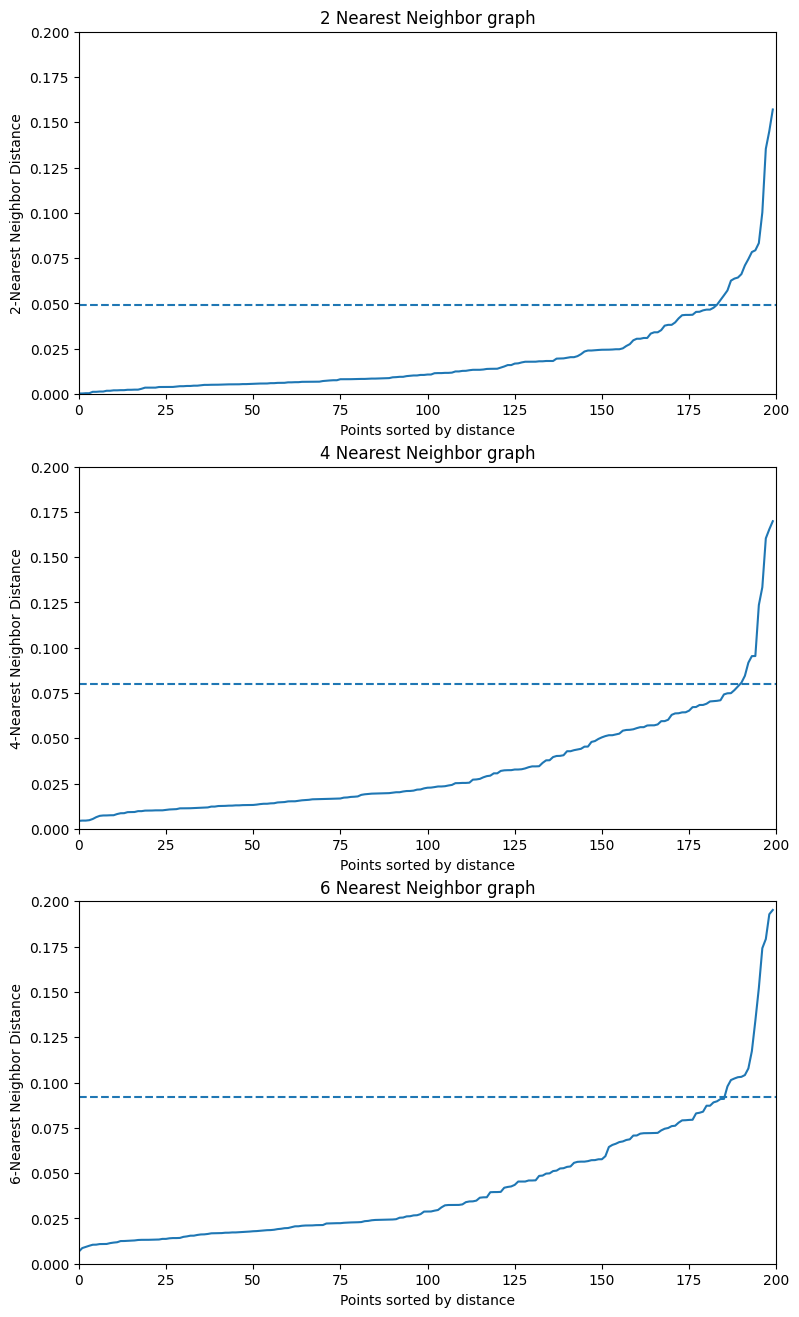

In [ ]:
plt.figure(figsize=(9, 16))

for i in range(0, 3):
    plt.subplot(3, 1, i + 1)
    plot_knn(data, minPts[i] - 1, eps[i])
    plt.xlim(0, len(data))
    plt.ylim(0, 0.2)

plt.show()

### 3.2 Clustering results

_**Note:**_ This section **is graded** by Themis.

Implement the function below to perform DBSCAN clustering and plot the resulting clusters and outliers, for the $\varepsilon$ and $minPts$ values found in 3.1.


In [99]:
def plot_db_scan(D, eps, k):
    """
    Perform DBSCAN and plot the resulting clusters.

    Args:
        D (ndarray): Data points.
        eps (float): The radius of the neighbourhood around a data point.
        k (int): The minimum number of points to form a dense region (MinPts).
    """
    
    pass


### 3.3 Quantitative result

*__Note:__* This section **is not graded** by Themis.

Compute and return the silhouette score for the different parameter settings found in 3.1 (in total, 3 silhouette scores). You can use `sklearn.metrics.silhouette_score`.


In [100]:
# Compute silhouette scores for the parameter settings found in section 3.1
# Replace eps_values and minpts_values with the values you determined

pass

Fill in the silhouette scores obtained for each parameter setting:

| $k$ (MinPts) | $\varepsilon$ | Silhouette Score |
|:---:|:---:|:---:|
| 2 | | |
| 3 | | |
| 4 | | |

## 4. Discussion (2 points)

Discuss your observations on both the qualitative and quantitative results, and conclusions for the best choice of parameter settings.

**Your answer here:**


## Contribution

State your individual contribution.

**Your answer here:**